In [2]:
import sys
print(sys.executable)

/opt/anaconda3/envs/dl_env/bin/python


                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Dataset Shape: (575061, 31)
Epoch 1/30  Loss: 0.004714
Epoch 2/30  Loss: 0.001312
Epoch 3/30  Loss: 0.000306
Epoch 4/30  Loss: 0.000128
Epoch 5/30  Loss: 0.000477
Epoch 6/30  Loss: 0.000737
Epoch 7/30  

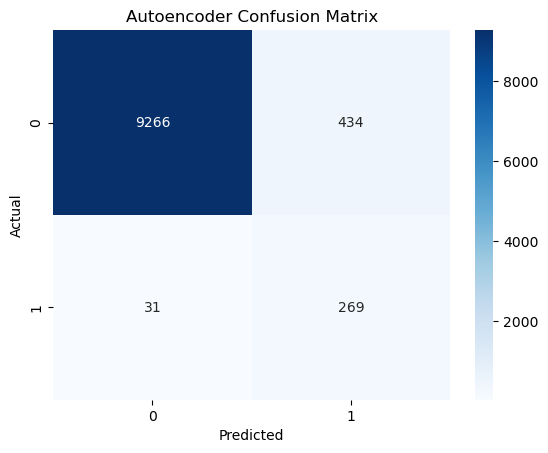

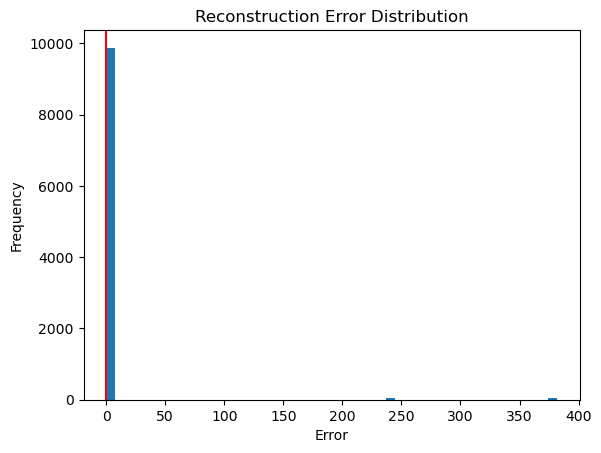

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv("../../Processed_data/processed_hdfs.csv")

print(df.head())
print("Dataset Shape:", df.shape)

# Feature selection
X = df.drop(["BlockId","Label"], axis=1)
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# Log transform
X = np.log1p(X)
y = df["Label"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Reduce size for training
X_train = X_train[:50000]
y_train = y_train[:50000]
X_test = X_test[:10000]
y_test = y_test[:10000]

# Train only on normal data
X_train_normal = X_train[y_train == 0]

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

# Convert to float32
X_train_scaled = X_train_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")

# Convert to PyTorch tensors
train_tensor = torch.tensor(X_train_scaled)
test_tensor = torch.tensor(X_test_scaled)
train_dataset = TensorDataset(train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Autoencoder Model
class AutoEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )

        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

input_dim = X_train_scaled.shape[1]
model = AutoEncoder(input_dim)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 30
for epoch in range(epochs):
    for batch in train_loader:
        inputs = batch[0]
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}  Loss: {loss.item():.6f}")

# Reconstruction error (train)
with torch.no_grad():
    train_recon = model(train_tensor)
train_mse = torch.mean((train_tensor - train_recon)**2, dim=1).numpy()
threshold = np.percentile(train_mse, 95)
print("Threshold:", threshold)

# Reconstruction error (test)
with torch.no_grad():
    test_recon = model(test_tensor)
mse = torch.mean((test_tensor - test_recon)**2, dim=1).numpy()

# Predict anomalies
y_pred = (mse > threshold).astype(int)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Autoencoder Confusion Matrix")

plt.show()

# Error distribution
plt.hist(mse, bins=50)
plt.axvline(threshold, color='red')
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

Epoch 1/30 Loss: 0.003796
Epoch 2/30 Loss: 0.001753
Epoch 3/30 Loss: 0.005202
Epoch 4/30 Loss: 0.003417
Epoch 5/30 Loss: 0.002647
Epoch 6/30 Loss: 0.005043
Epoch 7/30 Loss: 0.000904
Epoch 8/30 Loss: 0.003126
Epoch 9/30 Loss: 0.005191
Epoch 10/30 Loss: 0.004263
Epoch 11/30 Loss: 0.002207
Epoch 12/30 Loss: 0.002704
Epoch 13/30 Loss: 0.003036
Epoch 14/30 Loss: 0.003489
Epoch 15/30 Loss: 0.004463
Epoch 16/30 Loss: 0.002798
Epoch 17/30 Loss: 0.001895
Epoch 18/30 Loss: 0.001344
Epoch 19/30 Loss: 0.001739
Epoch 20/30 Loss: 0.005552
Epoch 21/30 Loss: 0.001496
Epoch 22/30 Loss: 0.002458
Epoch 23/30 Loss: 0.003193
Epoch 24/30 Loss: 0.004817
Epoch 25/30 Loss: 0.004111
Epoch 26/30 Loss: 0.001850
Epoch 27/30 Loss: 0.000719
Epoch 28/30 Loss: 0.000942
Epoch 29/30 Loss: 0.004312
Epoch 30/30 Loss: 0.001615


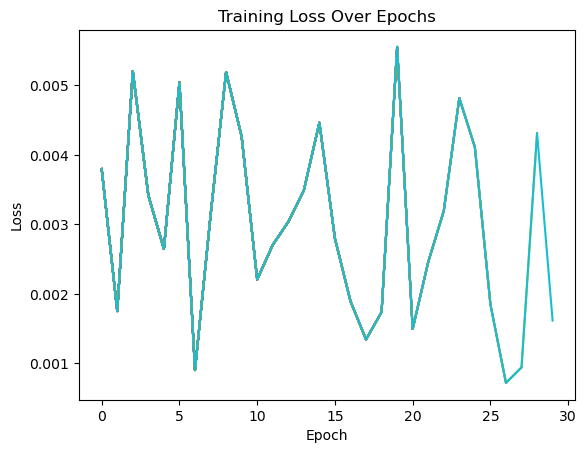

In [2]:
'''Training vs Validation Loss Plot, it visualizes overfitting / underfitting, record loss during training.'''
train_losses = []
epochs = 30
for epoch in range(epochs):
    epoch_loss = 0
    for batch in train_loader:
        inputs = batch[0]
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.6f}")
    plt.plot(train_losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [3]:
#Detection Rate & False Alarm Rate
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
detection_rate = TP / (TP + FN)
false_alarm_rate = FP / (FP + TN)
print("Detection Rate:", detection_rate)
print("False Alarm Rate:", false_alarm_rate)

Detection Rate: 0.8966666666666666
False Alarm Rate: 0.04474226804123711


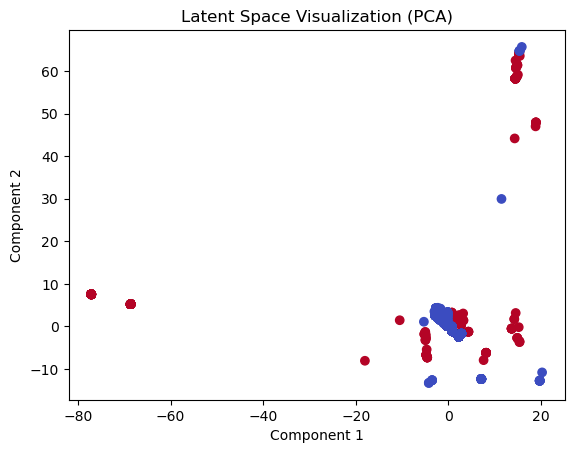

'If your model works well:\nnormal logs cluster together\nanomalies appear separate\n'

In [4]:
'''Latent Space Visualization (PCA)
~Extract encoded features:'''
with torch.no_grad():
    latent_features = model.encoder(test_tensor).numpy()
#Apply PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_features)
plt.scatter(latent_2d[:,0], latent_2d[:,1], c=y_test, cmap="coolwarm")
plt.title("Latent Space Visualization (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()
'''If your model works well:
normal logs cluster together
anomalies appear separate
'''

In [ ]:
'''Model Stability Check
Train the model with different random seeds.'''
import random
seeds = [0, 42, 100]
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    model = AutoEncoder(input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(5):
        for batch in train_loader:
            inputs = batch[0]
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    print(f"Training completed with seed {seed}")

Training completed with seed 0
Training completed with seed 42
Training completed with seed 100
